# The Bratu problem: Newton's method on an automatically sparse Jacobian

The Bratu (or Liouville–Gelfand) equation models thermal ignition of a solid fuel:

$$
-\Delta u = \lambda e^{u} \ \text{ in } \Omega = (0, 1)^2, \qquad u = 0 \ \text{ on } \partial\Omega .
$$

It has a solution only for $\lambda$ below a critical value $\lambda^\star \approx 6.808$ (the
turning point of the solution branch). Discretized with the five-point stencil on an
$n \times n$ interior grid it is a system of $n^2$ nonlinear equations with a sparse Jacobian.

The point of this notebook: the residual is written **densely**, as slices of a padded 2-D array
the way one would write it in NumPy. Scaly discovers the sparsity, colours it, builds a compact
Jacobian, factors it with a generated sparse $LDL^\top$ and runs Newton's method — all inside one
generated C function.

| Scaly feature | Where |
| --- | --- |
| `sc.jacobian_sparsity`, `sc.column_coloring` | the five-point pattern, found from the graph |
| `sc.sparse_jacobian` → `SparseMatrix.from_sparse_jacobian` | compact Jacobian values on a static pattern |
| `linalg.SparseLDL`, `.solve`, `.inertia()` | fill-reducing ordering at build time, factorization loops in C |
| `sc.while_loop` with `params` | Newton's iteration with $\lambda$ as a loop parameter |

The script version is `examples/bratu_newton.py`.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

import plotstyle
import scaly as sc
from scaly import linalg
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "bratu_newton"

## The residual, written densely

With $h = 1/(n+1)$ and the grid values padded by the zero boundary,

$$
F(u)_{ij} = \frac{4u_{ij} - u_{i-1,j} - u_{i+1,j} - u_{i,j-1} - u_{i,j+1}}{h^2} - \lambda e^{u_{ij}} .
$$

In [2]:
def residual(u, lam, n):
  h = 1.0 / (n + 1)
  grid = u.reshape((n, n))
  col, row = sc.const(np.zeros((n, 1))), sc.const(np.zeros((1, n + 2)))
  padded = sc.concat([row, sc.concat([col, grid, col], axis=1), row])
  lap = (4 * grid - padded[:-2, 1:-1] - padded[2:, 1:-1] - padded[1:-1, :-2] - padded[1:-1, 2:]) / h**2
  return (lap - lam * grid.exp()).reshape((n * n,))

## Sparsity and colouring, from the graph alone

`sc.jacobian_sparsity` propagates dependencies through the slices, the concatenation and the
elementwise operations, and returns the structural pattern of $\partial F/\partial u$: exactly the
five-point stencil. `sc.column_coloring` then groups columns that share no row, so one forward-mode
seed per colour recovers all their entries at once. The number of colours does not grow with the
grid, so the compact Jacobian costs a fixed number of forward sweeps however fine the grid.

In [3]:
for n in (10, 20, 40, 80, 160):
  u, lam = sc.sym("u", n * n), sc.sym("lam", ())
  pattern = sc.jacobian_sparsity(residual(u, lam, n), u)
  colors = np.array(sc.column_coloring(pattern))
  print(f"n = {n:3d}: {n * n:6d} unknowns, {pattern.nnz:7d} nonzeros ({100 * pattern.nnz / (n * n) ** 2:.3f}% dense), {colors.max() + 1} colours")

n =  10:    100 unknowns,     460 nonzeros (4.600% dense), 7 colours
n =  20:    400 unknowns,    1920 nonzeros (1.200% dense), 7 colours
n =  40:   1600 unknowns,    7840 nonzeros (0.306% dense), 7 colours
n =  80:   6400 unknowns,   31680 nonzeros (0.077% dense), 7 colours


n = 160:  25600 unknowns,  127360 nonzeros (0.019% dense), 7 colours


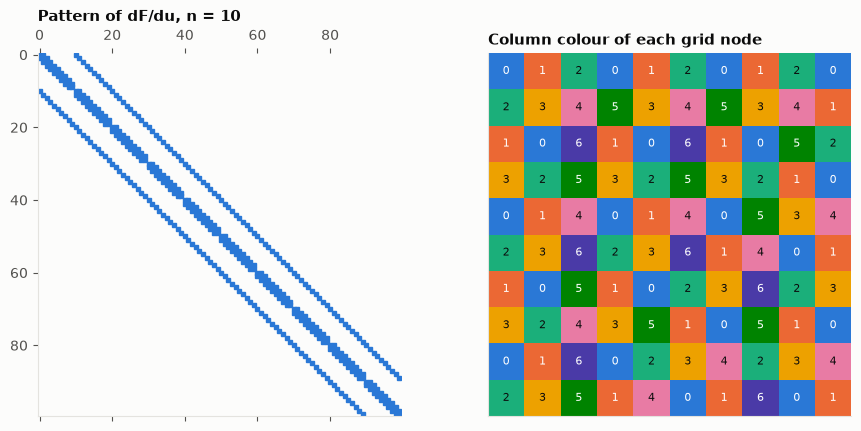

In [4]:
n_small = 10
u, lam = sc.sym("u", n_small**2), sc.sym("lam", ())
pattern = sc.jacobian_sparsity(residual(u, lam, n_small), u)
colors = np.array(sc.column_coloring(pattern))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4.2))
ax1.spy(pattern.to_mask(), markersize=2.5, color=plotstyle.BLUE)
ax1.set_title(f"Pattern of dF/du, n = {n_small}")
ax1.grid(False)
cmap = ListedColormap(plotstyle.SERIES[: colors.max() + 1])
ax2.imshow(colors.reshape(n_small, n_small), cmap=cmap, interpolation="nearest")
for (i, j), c in np.ndenumerate(colors.reshape(n_small, n_small)):
  ax2.text(j, i, str(c), ha="center", va="center", fontsize=8, color=plotstyle.TEXT if c in (2, 3, 4) else "white")  # dark ink on the light slots
ax2.set_title("Column colour of each grid node")
ax2.set_xticks([])
ax2.set_yticks([])
ax2.grid(False)
plt.show()

Every node's five-point neighbourhood (itself and four neighbours) must see distinct colours for
the compression to be exact; the greedy colouring uses seven where five would do, still a constant.

## Newton's method, one C function

`newton_step` forms the residual, the compact Jacobian as a `SparseMatrix`, factors it with
`SparseLDL` (whose symbolic analysis — ordering, elimination tree, pattern of $L$ — happens once,
when the graph is built) and solves. On the lower solution branch the Jacobian
$-\Delta_h - \lambda\,\mathrm{diag}(e^u)$ is positive definite, which `inertia()` (the signs of the
pivots) confirms. `bratu_solve` wraps the step in a `while_loop` that stops when $\lVert F\rVert_\infty < 10^{-10}$.

In [5]:
N_GRID, TOL, MAX_NEWTON = 40, 1e-10, 30
nn = N_GRID * N_GRID


@sc.function(sc.G(sc.L("u", nn), sc.L("lam", ())), output=sc.G(sc.L("u_next", nn), sc.L("inertia", 3), sc.L("residual", ())))
def newton_step(inputs):
  u, lam = inputs
  f = residual(u, lam, N_GRID)
  jac = linalg.SparseMatrix.from_sparse_jacobian(sc.sparse_jacobian(f, u))
  fact = linalg.SparseLDL(jac, name="bratu")
  return u - fact.solve(f), fact.inertia(), sc.norm_inf(f)


@sc.function(sc.G(sc.L("carry", nn + 1), sc.L("lam", ())), output=sc.L("carry_next", nn + 1))
def body(inputs):
  carry, lam = inputs
  u_next, _, _ = newton_step((carry[:nn], lam))
  return sc.concat([u_next, sc.norm_inf(residual(u_next, lam, N_GRID)).reshape((1,))])


@sc.function(sc.G(sc.L("carry", nn + 1), sc.L("lam", ())), output=sc.L("go_on", ...))
def not_converged(inputs):
  return sc.greater(inputs[0][nn], TOL)


@sc.function(sc.G(sc.L("u0", nn), sc.L("lam", ())), output=sc.G(sc.L("u", nn), sc.L("residual", ()), sc.L("iterations", ()), sc.L("inertia", 3)))
def bratu_solve(inputs):
  u0, lam = inputs
  start = sc.concat([u0, sc.norm_inf(residual(u0, lam, N_GRID)).reshape((1,))])
  carry, n_iter = sc.while_loop(not_converged, body, start, max_iter=MAX_NEWTON, params=(lam,))
  _, inertia, _ = newton_step((carry[:nn], lam))
  return carry[:nn], carry[nn], n_iter, inertia

### Quadratic convergence

`newton_step` is itself a callable `Function`, so the iteration can be stepped from Python to watch
it. From $u = 0$ at $\lambda = 6$ the residual falls quadratically once Newton's region of
attraction is reached.

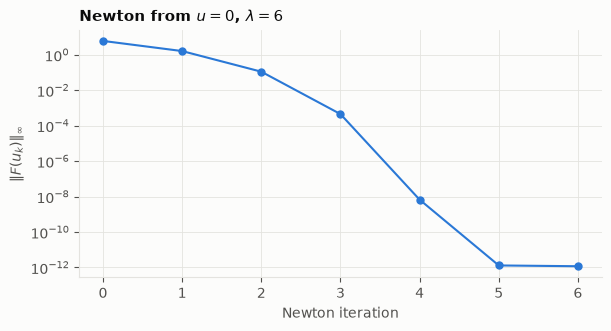

In [6]:
u_it, history = np.zeros(nn), []
for _ in range(7):
  u_next, inertia, res = newton_step((u_it, np.array(6.0)))
  history.append(float(res))
  u_it = u_next
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.semilogy(history, "o-", color=plotstyle.BLUE, lw=1.5)
ax.set_xlabel("Newton iteration")
ax.set_ylabel(r"$\|F(u_k)\|_\infty$")
ax.set_title(r"Newton from $u = 0$, $\lambda = 6$")
plt.show()

## Continuation towards the turning point

Natural-parameter continuation: solve for increasing $\lambda$, warm-starting each solve from the
previous solution. Each solve is one call of the generated function.

In [7]:
lambdas = np.r_[np.linspace(0.25, 6.5, 26), 6.6, 6.7, 6.75, 6.78, 6.8]
u_c, rows = np.zeros(nn), []
bratu_solve((u_c, np.array(1.0)))  # compile
start = time.perf_counter()
for lam_value in lambdas:
  u_c, res, iterations, inertia = bratu_solve((u_c, np.array(lam_value)))
  rows.append((lam_value, u_c.max(), res, int(iterations), inertia))
elapsed = time.perf_counter() - start
print(f"{len(lambdas)} solves with {nn} unknowns in {1e3 * elapsed:.1f} ms ({1e3 * elapsed / len(lambdas):.2f} ms per solve)")
print("all pivots positive:", all(int(r[4][0]) == nn for r in rows), "| largest final residual:", f"{max(r[2] for r in rows):.1e}")
print("Newton steps per solve:", [r[3] for r in rows])

31 solves with 1600 unknowns in 58.7 ms (1.89 ms per solve)
all pivots positive: True | largest final residual: 5.9e-11
Newton steps per solve: [2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5]


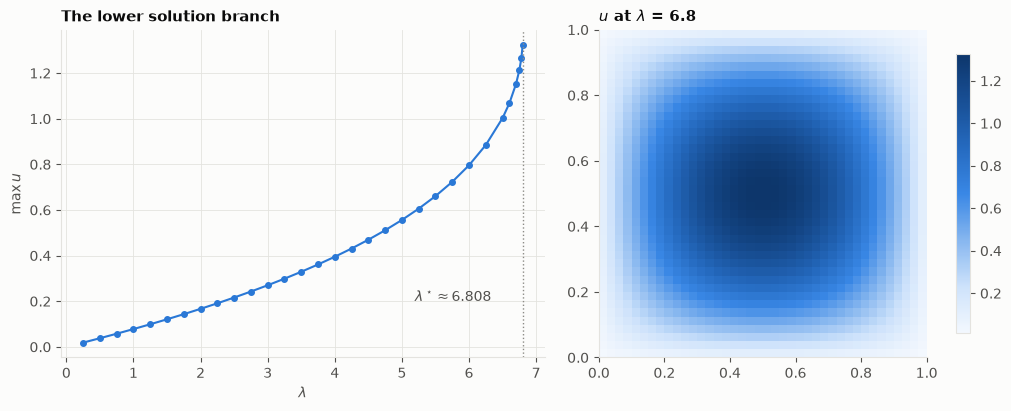

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={"width_ratios": [1.3, 1]})
ax1.plot([r[0] for r in rows], [r[1] for r in rows], "o-", ms=4, color=plotstyle.BLUE, lw=1.5)
ax1.axvline(6.808, color=plotstyle.NEUTRAL, lw=1, ls=":")
ax1.annotate(r"$\lambda^\star \approx 6.808$", (6.808, 0.2), xytext=(-78, 0), textcoords="offset points", color=plotstyle.TEXT_SECONDARY)
ax1.set_xlabel(r"$\lambda$")
ax1.set_ylabel(r"$\max u$")
ax1.set_title("The lower solution branch")
image = ax2.imshow(u_c.reshape(N_GRID, N_GRID), cmap=plotstyle.BLUES, extent=(0, 1, 0, 1), origin="lower")
fig.colorbar(image, ax=ax2, shrink=0.85)
ax2.set_title(rf"$u$ at $\lambda$ = {lambdas[-1]}")
ax2.grid(False)
plt.show()

The branch steepens as $\lambda \to \lambda^\star$, where the Jacobian becomes singular and
natural-parameter continuation must stop (pseudo-arclength continuation would go round the fold
onto the unstable upper branch, where the inertia would show one negative pivot).

## The generated C

The whole Newton solver — residual, compact Jacobian, sparse factorization, solves and the loop —
is one C function. The pattern of $L$ and the loop tables are static data in the source.

In [9]:
module = write_module(bratu_solve, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB, workspace {module.workspace_size} doubles")

bratu_solve.c: 574 lines, 2265 kB, workspace 161530 doubles
